In [1]:
# Imports, plotting configuration, and run-wide constants
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from networks import load_arm
from modelling import (
    load_vix, split_train_test, cluster_kmeans, cluster_hmm, fit_regime_order, validate_regime, empirical_transitions,
)
from eigencentrality import window_centrality, fit_centrality_embed, transform_centrality_embed
from plot_style import (
    set_publication_style, style_axis, shade_periods, format_date_axis, mark_split, annotate_events,
    REGIME_PALETTE, CRISIS_EVENTS, EPOCH_LENGTH_COLOURS,
)

set_publication_style()

k = 3
INDEX_CODE = "SP500"
ARM = "raw"
EPOCH_LENGTH = 132
GRAPH_TYPE = "mst"
GRAPH_KEY = "mst_threshold_graphs"
TRAIN_TEST_CUTOFF = "2019-12-31"
REGIME_NAMES = ["Calm", "Transitional", "Crisis"]

In [2]:
# Load the raw arm's MST-threshold networks for S&P 500, split train/test, and the VIX series
arm_data = load_arm(ARM, EPOCH_LENGTH, index_code=INDEX_CODE)
train, test = split_train_test(arm_data, cutoff=TRAIN_TEST_CUTOFF)
stock_names = arm_data["stock_names"]
train_graphs, test_graphs = train[GRAPH_KEY], test[GRAPH_KEY]
train_mu, test_mu = train["mu_values"], test["mu_values"]
train_dates, test_dates = train["epoch_dates"], test["epoch_dates"]
n_train_windows = len(train_dates)
vix = load_vix()
print(f"train windows: {n_train_windows}, test windows: {len(test_dates)}")

train windows: 465, test windows: 164


In [3]:
# Step 1 -- localisation gate: per-window eigenvector-centrality diagnostics on the LCC
window_stats = pd.DataFrame([window_centrality(G, stock_names) for G in train_graphs + test_graphs])

mean_pr, median_pr = window_stats["pr"].mean(), window_stats["pr"].median()
mean_lcc_frac = window_stats["lcc_frac"].mean()
print(f"mean PR {mean_pr:.2f}  median PR {median_pr:.2f}  mean lcc_frac {mean_lcc_frac:.3f}")

if mean_pr < 10:
    print(f"FLAG: mean PR ({mean_pr:.2f}) is below 10 out of N -- v1 has localised onto a hub; "
          f"the regime clustering below is a diagnosis of that pathology, not a clean benchmark result.")

mean PR 51.51  median PR 32.59  mean lcc_frac 1.000


In [4]:
# Step 1 summary -- mean/median PR, mean lcc_frac, and modal argmax_id (the topological centre)
summary_table = pd.DataFrame([{
    "graph_type": GRAPH_TYPE,
    "mean_pr": mean_pr,
    "median_pr": median_pr,
    "mean_lcc_frac": mean_lcc_frac,
    "modal_argmax_id": window_stats["argmax_id"].mode().iat[0],
}])
summary_table

,graph_type,mean_pr,median_pr,mean_lcc_frac,modal_argmax_id
0,mst,51.510675,32.587668,1.0,FIN_BEN


In [5]:
# Embed the graphs: raw-indexed eigenvector centrality -> StandardScaler -> PCA(0.95), fit on train, transform both
raw_centrality_matrix = np.stack(window_stats["v1"].tolist())
X_train, scaler, pca, fit_diag = fit_centrality_embed(raw_centrality_matrix[:n_train_windows])
X_test = transform_centrality_embed(raw_centrality_matrix[n_train_windows:], scaler, pca)
print(f"PCA-reduced embedding: train {X_train.shape[0]} x {X_train.shape[1]}, test {X_test.shape[0]} x {X_test.shape[1]}")
print(f"Retained PCA dimensions: {fit_diag['pca_dims']}")

PCA-reduced embedding: train 465 x 65, test 164 x 65
Retained PCA dimensions: 65


In [6]:
# Fit K-means (k=3) on train, predict both, mu-rank the regimes from train only
km_train_labels, km_test_labels, km_model = cluster_kmeans(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(km_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

km_order = order

Mean μ per regime (train): {0: np.float64(0.552), 1: np.float64(0.248), 2: np.float64(0.328)}
Crisis regime: 0


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


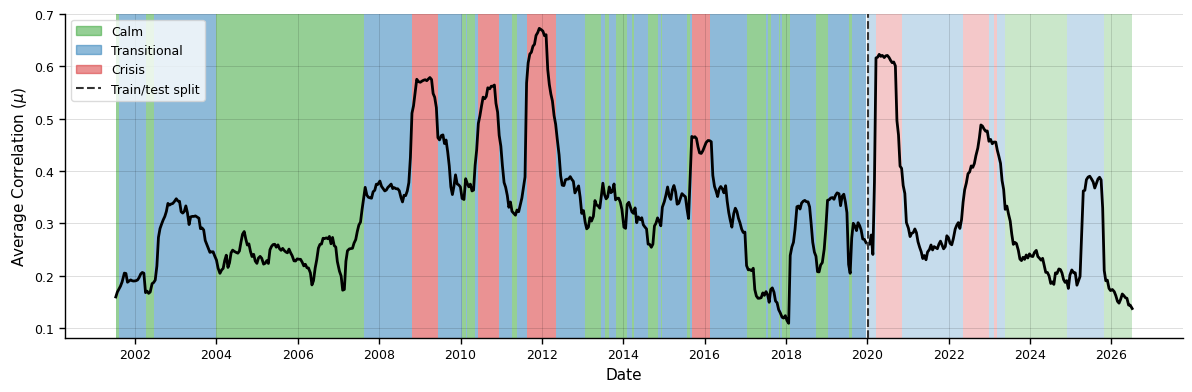

In [7]:
# Regime timeline shaded by mu-rank (K-means) -- train and test on one continuous axis
def plot_regime_timeline(train_dates, train_mu, train_labels, test_dates, test_mu, test_labels, rank_of_cluster):
    fig, ax = plt.subplots(figsize=(12, 4))

    def shade(dates, labels, alpha):
        for r in range(k):
            intervals = [(dates[i], dates[min(i + 1, len(dates) - 1)])
                         for i, lbl in enumerate(labels) if rank_of_cluster[lbl] == r]
            shade_periods(ax, intervals, REGIME_PALETTE[r], alpha=alpha)

    shade(train_dates, train_labels, alpha=0.5)
    shade(test_dates, test_labels, alpha=0.25)

    ax.plot(train_dates, train_mu, color="black", linewidth=2)
    ax.plot(test_dates, test_mu, color="black", linewidth=2)

    handles = [Patch(color=REGIME_PALETTE[r], alpha=0.5, label=REGIME_NAMES[r]) for r in range(k)]
    if len(test_dates) > 0:
        handles.append(mark_split(ax, test_dates[0]))

    ax.set_xlabel("Date")
    ax.set_ylabel(r"Average Correlation ($\mu$)")
    format_date_axis(ax)
    style_axis(ax, grid=True)
    ax.legend(handles=handles, loc="upper left", frameon=True, facecolor="white", edgecolor="lightgray")
    plt.tight_layout()
    plt.show()

plot_regime_timeline(train_dates, train_mu, km_train_labels, test_dates, test_mu, km_test_labels, rank_of_cluster)

In [8]:
# VIX validation F1 (K-means) -- train and test separately
res_train = validate_regime(km_train_labels, train_dates, vix, 30.0, crisis_id)
res_test = validate_regime(km_test_labels, test_dates, vix, 30.0, crisis_id)
print("train  point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_train["point"]))
print("test   point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_test["point"]))

train  point-in-time  precision 0.397  recall 0.479  F1 0.434
test   point-in-time  precision 0.294  recall 0.625  F1 0.400


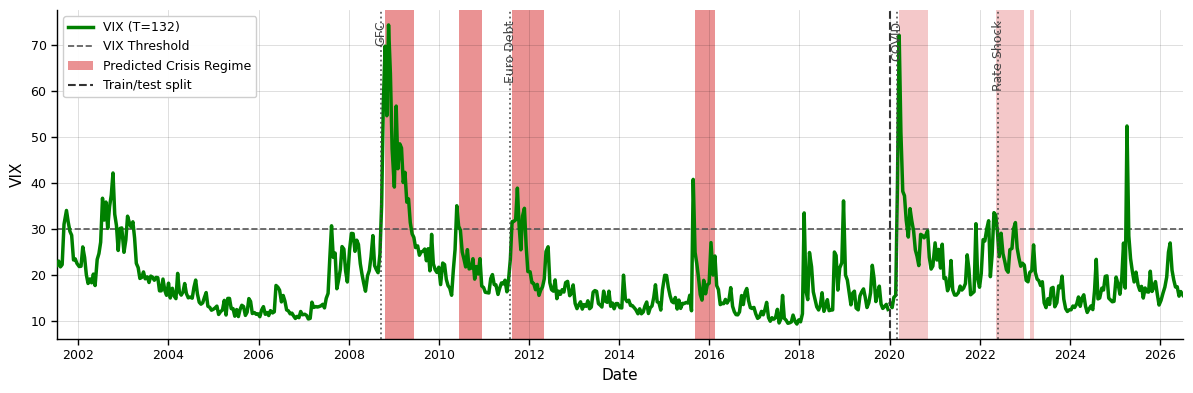

In [9]:
# VIX overlay with predicted-crisis shading, train and test on one continuous axis
def plot_vix_overlay(train_dates, res_train, test_dates, res_test):
    idx_train = pd.DatetimeIndex(pd.to_datetime(train_dates))
    idx_test = pd.DatetimeIndex(pd.to_datetime(test_dates))
    vix_color = EPOCH_LENGTH_COLOURS[EPOCH_LENGTH]
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(idx_train, res_train["series_eod"], color=vix_color, linewidth=2.5, zorder=3)
    ax.plot(idx_test, res_test["series_eod"], color=vix_color, linewidth=2.5, zorder=3)
    ax.axhline(30.0, color="#555555", linestyle="--", linewidth=1.2, zorder=2)

    def shade_crisis(idx, res, alpha):
        crisis_idx = np.where(res["pred"].astype(bool))[0]
        intervals = [(idx[i], idx[min(i + 1, len(idx) - 1)]) for i in crisis_idx]
        shade_periods(ax, intervals, REGIME_PALETTE[2], alpha=alpha)

    shade_crisis(idx_train, res_train, alpha=0.5)
    shade_crisis(idx_test, res_test, alpha=0.25)

    idx_all = idx_train.append(idx_test)
    annotate_events(ax, CRISIS_EVENTS, idx_all[0], idx_all[-1])

    handles = [Line2D([0], [0], color=vix_color, lw=2.5, label=f"VIX (T={EPOCH_LENGTH})"),
               Line2D([0], [0], color="#555555", lw=1.2, linestyle="--", label="VIX Threshold"),
               Patch(facecolor=REGIME_PALETTE[2], alpha=0.5, label="Predicted Crisis Regime")]
    if len(idx_test) > 0:
        handles.append(mark_split(ax, idx_test[0]))

    ax.set_xlabel("Date")
    ax.set_ylabel("VIX")
    ax.set_xlim(idx_all[0], idx_all[-1])
    format_date_axis(ax)
    style_axis(ax, grid=True)
    ax.legend(handles=handles, loc="upper left", frameon=True, framealpha=0.95, edgecolor="#CCCCCC")
    plt.tight_layout()
    plt.show()

plot_vix_overlay(train_dates, res_train, test_dates, res_test)

In [10]:
# Fit best-of-20 HMM on train, predict both, mu-rank the regimes from train only
hmm_train_labels, hmm_test_labels, hmm_model = cluster_hmm(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(hmm_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Mean μ per regime (train): {0: np.float64(0.4), 1: np.float64(0.243), 2: np.float64(0.315)}
Crisis regime: 0


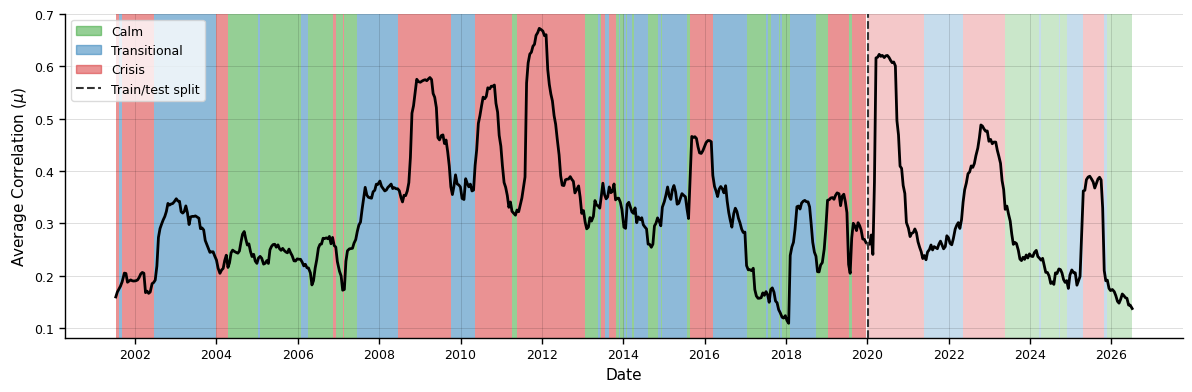

In [11]:
# Regime timeline shaded by mu-rank (HMM) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, hmm_train_labels, test_dates, test_mu, hmm_test_labels, rank_of_cluster)

In [12]:
# Empirical train/test transition matrices for both clustering methods
emp_km_train, occ_km_train = empirical_transitions(km_train_labels, k, km_order)
emp_km_test, occ_km_test = empirical_transitions(km_test_labels, k, km_order)
print("K-means train transitions:\n", np.round(emp_km_train, 3), "\noccupancy:", occ_km_train)
print("K-means test transitions:\n", np.round(emp_km_test, 3), "\noccupancy:", occ_km_test)

emp_hmm_train, occ_hmm_train = empirical_transitions(hmm_train_labels, k, order)
emp_hmm_test, occ_hmm_test = empirical_transitions(hmm_test_labels, k, order)
print("\nHMM train transitions:\n", np.round(emp_hmm_train, 3), "\noccupancy:", occ_hmm_train)
print("HMM test transitions:\n", np.round(emp_hmm_test, 3), "\noccupancy:", occ_hmm_test)

K-means train transitions:
 [[0.886 0.114 0.   ]
 [0.075 0.908 0.017]
 [0.    0.069 0.931]] 
occupancy: [167 240  58]
K-means test transitions:
 [[0.982 0.018 0.   ]
 [0.027 0.932 0.041]
 [0.    0.088 0.912]] 
occupancy: [56 74 34]

HMM train transitions:
 [[0.835 0.11  0.055]
 [0.084 0.886 0.03 ]
 [0.041 0.029 0.93 ]] 
occupancy: [127 166 172]
HMM test transitions:
 [[0.941 0.059 0.   ]
 [0.079 0.868 0.053]
 [0.014 0.027 0.959]] 
occupancy: [52 38 74]


In [13]:
# VIX validation F1 (HMM) -- train and test separately
res_hmm_train = validate_regime(hmm_train_labels, train_dates, vix, 30.0, crisis_id)
res_hmm_test = validate_regime(hmm_test_labels, test_dates, vix, 30.0, crisis_id)
print("train  point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_hmm_train["point"]))
print("test   point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_hmm_test["point"]))

train  point-in-time  precision 0.174  recall 0.625  F1 0.273
test   point-in-time  precision 0.149  recall 0.688  F1 0.244


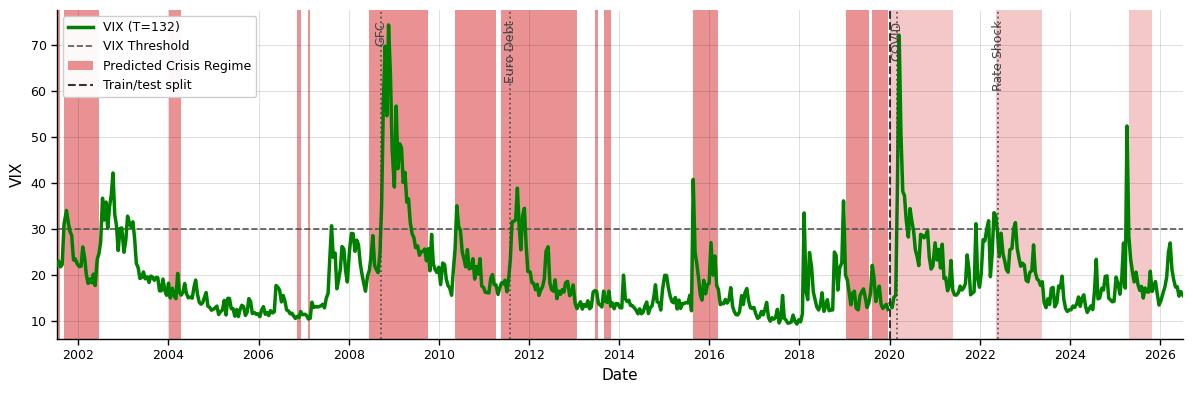

In [14]:
# VIX overlay with predicted-crisis shading (HMM), train and test on one continuous axis
plot_vix_overlay(train_dates, res_hmm_train, test_dates, res_hmm_test)

In [15]:
# Load the raw arm's MST-threshold networks for Nikkei 225 (no VIX-equivalent series, so no F1/VIX-overlay cells below)
INDEX_CODE = "Nikkei225"
arm_data = load_arm(ARM, EPOCH_LENGTH, index_code=INDEX_CODE)
train, test = split_train_test(arm_data, cutoff=TRAIN_TEST_CUTOFF)
stock_names = arm_data["stock_names"]
train_graphs, test_graphs = train[GRAPH_KEY], test[GRAPH_KEY]
train_mu, test_mu = train["mu_values"], test["mu_values"]
train_dates, test_dates = train["epoch_dates"], test["epoch_dates"]
n_train_windows = len(train_dates)
print(f"train windows: {n_train_windows}, test windows: {len(test_dates)}")

train windows: 453, test windows: 159


In [16]:
# Step 1 -- localisation gate: per-window eigenvector-centrality diagnostics on the LCC (Nikkei 225)
window_stats = pd.DataFrame([window_centrality(G, stock_names) for G in train_graphs + test_graphs])

mean_pr, median_pr = window_stats["pr"].mean(), window_stats["pr"].median()
mean_lcc_frac = window_stats["lcc_frac"].mean()
print(f"mean PR {mean_pr:.2f}  median PR {median_pr:.2f}  mean lcc_frac {mean_lcc_frac:.3f}")

if mean_pr < 10:
    print(f"FLAG: mean PR ({mean_pr:.2f}) is below 10 out of N -- v1 has localised onto a hub; "
          f"the regime clustering below is a diagnosis of that pathology, not a clean benchmark result.")

mean PR 32.99  median PR 22.78  mean lcc_frac 1.000


In [17]:
# Step 1 summary -- mean/median PR, mean lcc_frac, and modal argmax_id (the topological centre) (Nikkei 225)
summary_table = pd.DataFrame([{
    "graph_type": GRAPH_TYPE,
    "mean_pr": mean_pr,
    "median_pr": median_pr,
    "mean_lcc_frac": mean_lcc_frac,
    "modal_argmax_id": window_stats["argmax_id"].mode().iat[0],
}])
summary_table

,graph_type,mean_pr,median_pr,mean_lcc_frac,modal_argmax_id
0,mst,32.993347,22.783739,1.0,MACHIN_6473


In [18]:
# Embed the graphs: raw-indexed eigenvector centrality -> StandardScaler -> PCA(0.95), fit on train, transform both (Nikkei 225)
raw_centrality_matrix = np.stack(window_stats["v1"].tolist())
X_train, scaler, pca, fit_diag = fit_centrality_embed(raw_centrality_matrix[:n_train_windows])
X_test = transform_centrality_embed(raw_centrality_matrix[n_train_windows:], scaler, pca)
print(f"PCA-reduced embedding: train {X_train.shape[0]} x {X_train.shape[1]}, test {X_test.shape[0]} x {X_test.shape[1]}")
print(f"Retained PCA dimensions: {fit_diag['pca_dims']}")

PCA-reduced embedding: train 453 x 70, test 159 x 70
Retained PCA dimensions: 70


In [19]:
# Fit K-means (k=3) on train, predict both, mu-rank the regimes from train only (Nikkei 225)
km_train_labels, km_test_labels, km_model = cluster_kmeans(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(km_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

km_order = order

Mean μ per regime (train): {0: np.float64(0.4), 1: np.float64(0.309), 2: np.float64(0.436)}
Crisis regime: 2


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


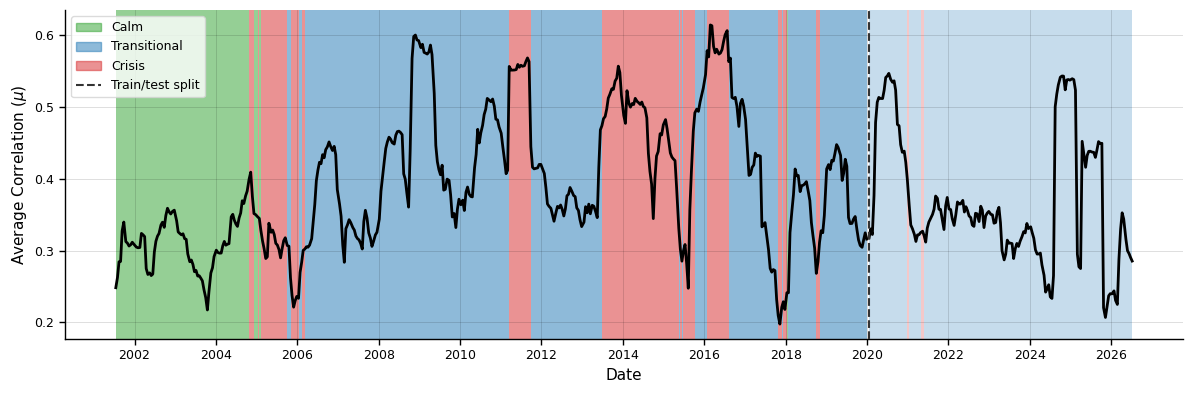

In [20]:
# Regime timeline shaded by mu-rank (K-means, Nikkei 225) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, km_train_labels, test_dates, test_mu, km_test_labels, rank_of_cluster)

In [21]:
# Fit best-of-20 HMM on train, predict both, mu-rank the regimes from train only (Nikkei 225)
hmm_train_labels, hmm_test_labels, hmm_model = cluster_hmm(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(hmm_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Mean μ per regime (train): {0: np.float64(0.364), 1: np.float64(0.429), 2: np.float64(0.311)}
Crisis regime: 1


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


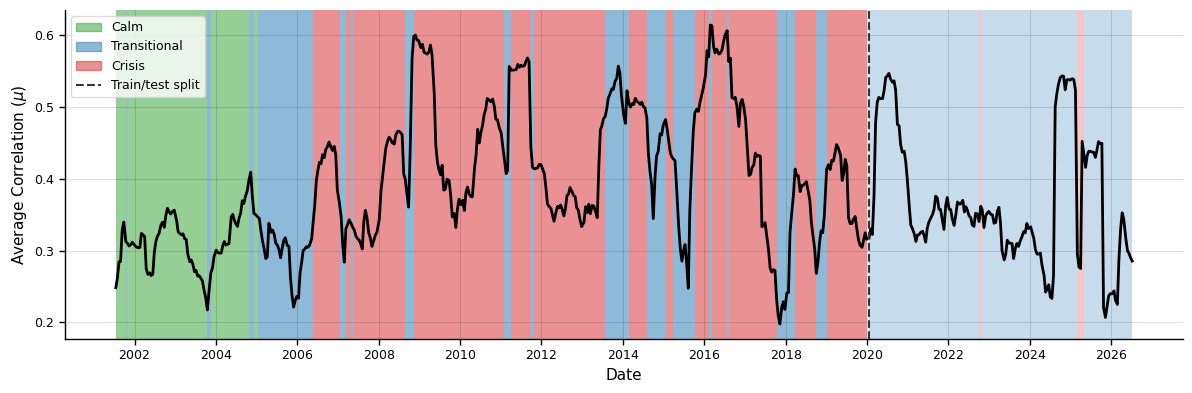

In [22]:
# Regime timeline shaded by mu-rank (HMM, Nikkei 225) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, hmm_train_labels, test_dates, test_mu, hmm_test_labels, rank_of_cluster)

In [23]:
# Empirical train/test transition matrices for both clustering methods (Nikkei 225)
emp_km_train, occ_km_train = empirical_transitions(km_train_labels, k, km_order)
emp_km_test, occ_km_test = empirical_transitions(km_test_labels, k, km_order)
print("K-means train transitions:\n", np.round(emp_km_train, 3), "\noccupancy:", occ_km_train)
print("K-means test transitions:\n", np.round(emp_km_test, 3), "\noccupancy:", occ_km_test)

emp_hmm_train, occ_hmm_train = empirical_transitions(hmm_train_labels, k, order)
emp_hmm_test, occ_hmm_test = empirical_transitions(hmm_test_labels, k, order)
print("\nHMM train transitions:\n", np.round(emp_hmm_train, 3), "\noccupancy:", occ_hmm_train)
print("HMM test transitions:\n", np.round(emp_hmm_test, 3), "\noccupancy:", occ_hmm_test)

K-means train transitions:
 [[0.952 0.012 0.036]
 [0.    0.961 0.039]
 [0.027 0.088 0.885]] 
occupancy: [ 84 256 113]
K-means test transitions:
 [[  nan   nan   nan]
 [0.    0.987 0.013]
 [0.    0.667 0.333]] 
occupancy: [  0 156   3]

HMM train transitions:
 [[0.949 0.051 0.   ]
 [0.026 0.86  0.114]
 [0.    0.05  0.95 ]] 
occupancy: [ 79 115 259]
HMM test transitions:
 [[  nan   nan   nan]
 [0.    0.987 0.013]
 [0.    0.333 0.667]] 
occupancy: [  0 153   6]
